<a href="https://colab.research.google.com/github/sravanisagara2721/CodeTech-ML-Internship/blob/main/Decisiion_Tree_Implimentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [3]:
# -------------------------------------------------------
# 1. LOAD DATASET
# -------------------------------------------------------
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target']  = iris.target
df['species'] = df['target'].map({0:'setosa', 1:'versicolor', 2:'virginica'})

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nClass Distribution:")
print(df['species'].value_counts())
print("\nNull Values:", df.isnull().sum().sum())

Dataset Shape: (150, 6)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Null Values: 0


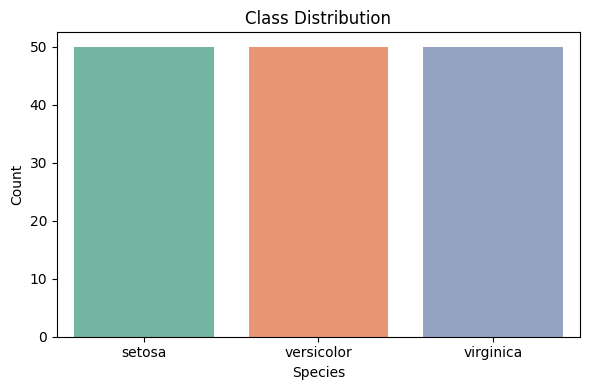

In [4]:
# -------------------------------------------------------
# 2. EDA - CLASS DISTRIBUTION PLOT
# -------------------------------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='species', data=df, palette='Set2')
plt.title('Class Distribution')
plt.xlabel('Species')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


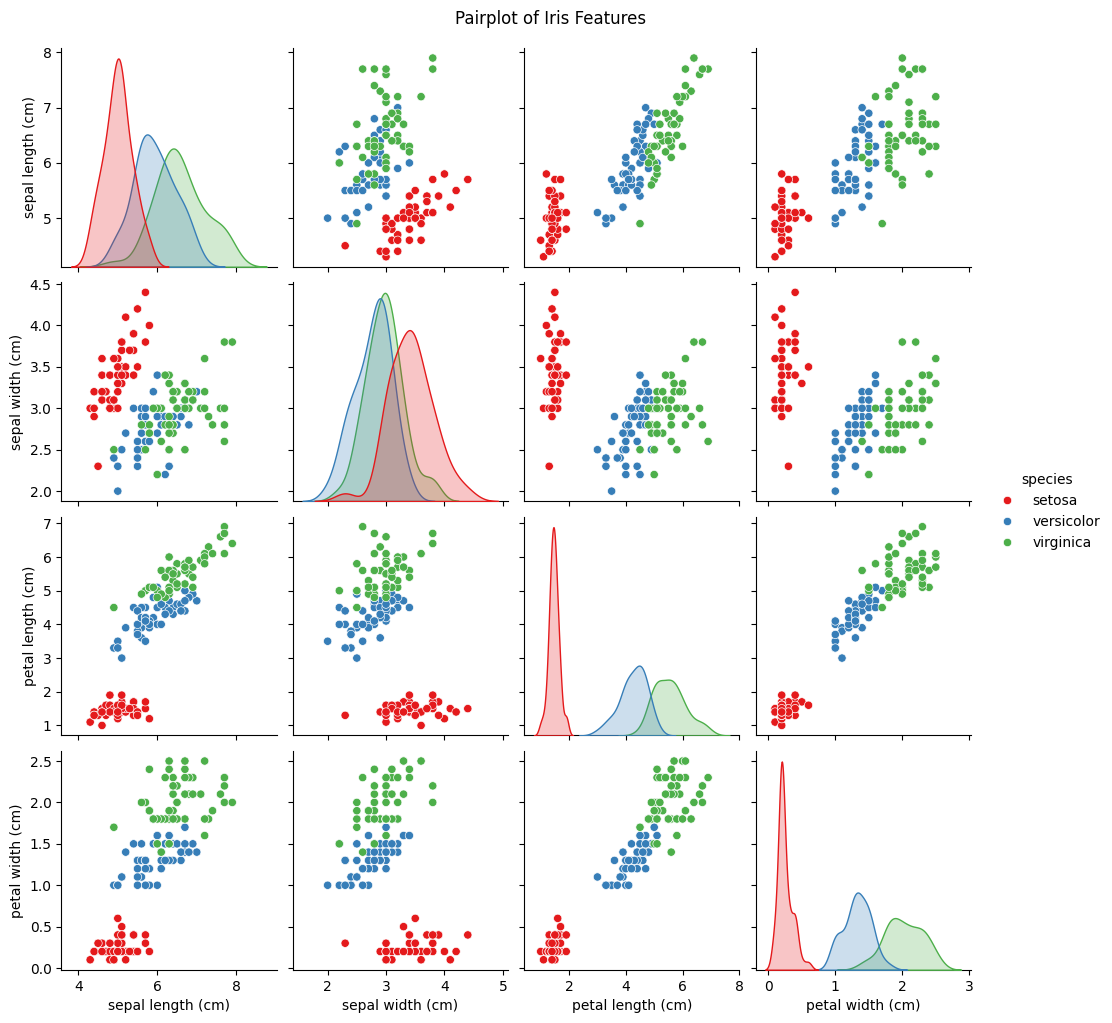

In [5]:
# -------------------------------------------------------
# 3. EDA - PAIRPLOT
# -------------------------------------------------------
sns.pairplot(df, hue='species', vars=iris.feature_names, palette='Set1')
plt.suptitle('Pairplot of Iris Features', y=1.02)
plt.show()

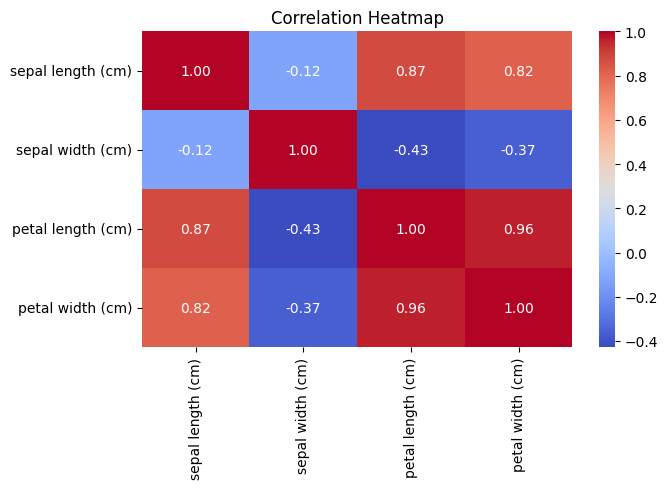

In [6]:
# -------------------------------------------------------
# 4. EDA - CORRELATION HEATMAP
# -------------------------------------------------------
plt.figure(figsize=(7,5))
sns.heatmap(df[iris.feature_names].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [8]:
# -------------------------------------------------------
# 5. TRAIN / TEST SPLIT
# -------------------------------------------------------
X = df[iris.feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTraining size:", X_train.shape)
print("Testing size :", X_test.shape)


Training size: (120, 4)
Testing size : (30, 4)


In [9]:
# -------------------------------------------------------
# 6. BUILD DECISION TREE MODEL
# -------------------------------------------------------
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
model.fit(X_train, y_train)

print("\nModel trained!")
print("Tree Depth  :", model.get_depth())
print("No. of Leaves:", model.get_n_leaves())



Model trained!
Tree Depth  : 3
No. of Leaves: 5


In [10]:
# -------------------------------------------------------
# 7. PREDICTIONS & ACCURACY
# -------------------------------------------------------
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc * 100:.2f}%")


Test Accuracy: 96.67%


In [11]:
# -------------------------------------------------------
# 8. CLASSIFICATION REPORT
# -------------------------------------------------------
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))



Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



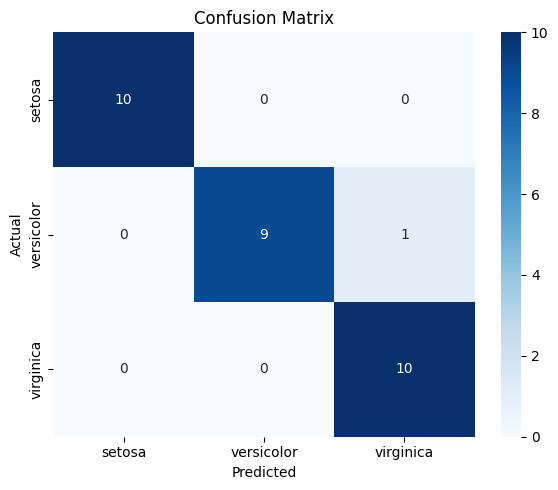

In [12]:
# -------------------------------------------------------
# 9. CONFUSION MATRIX
# -------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

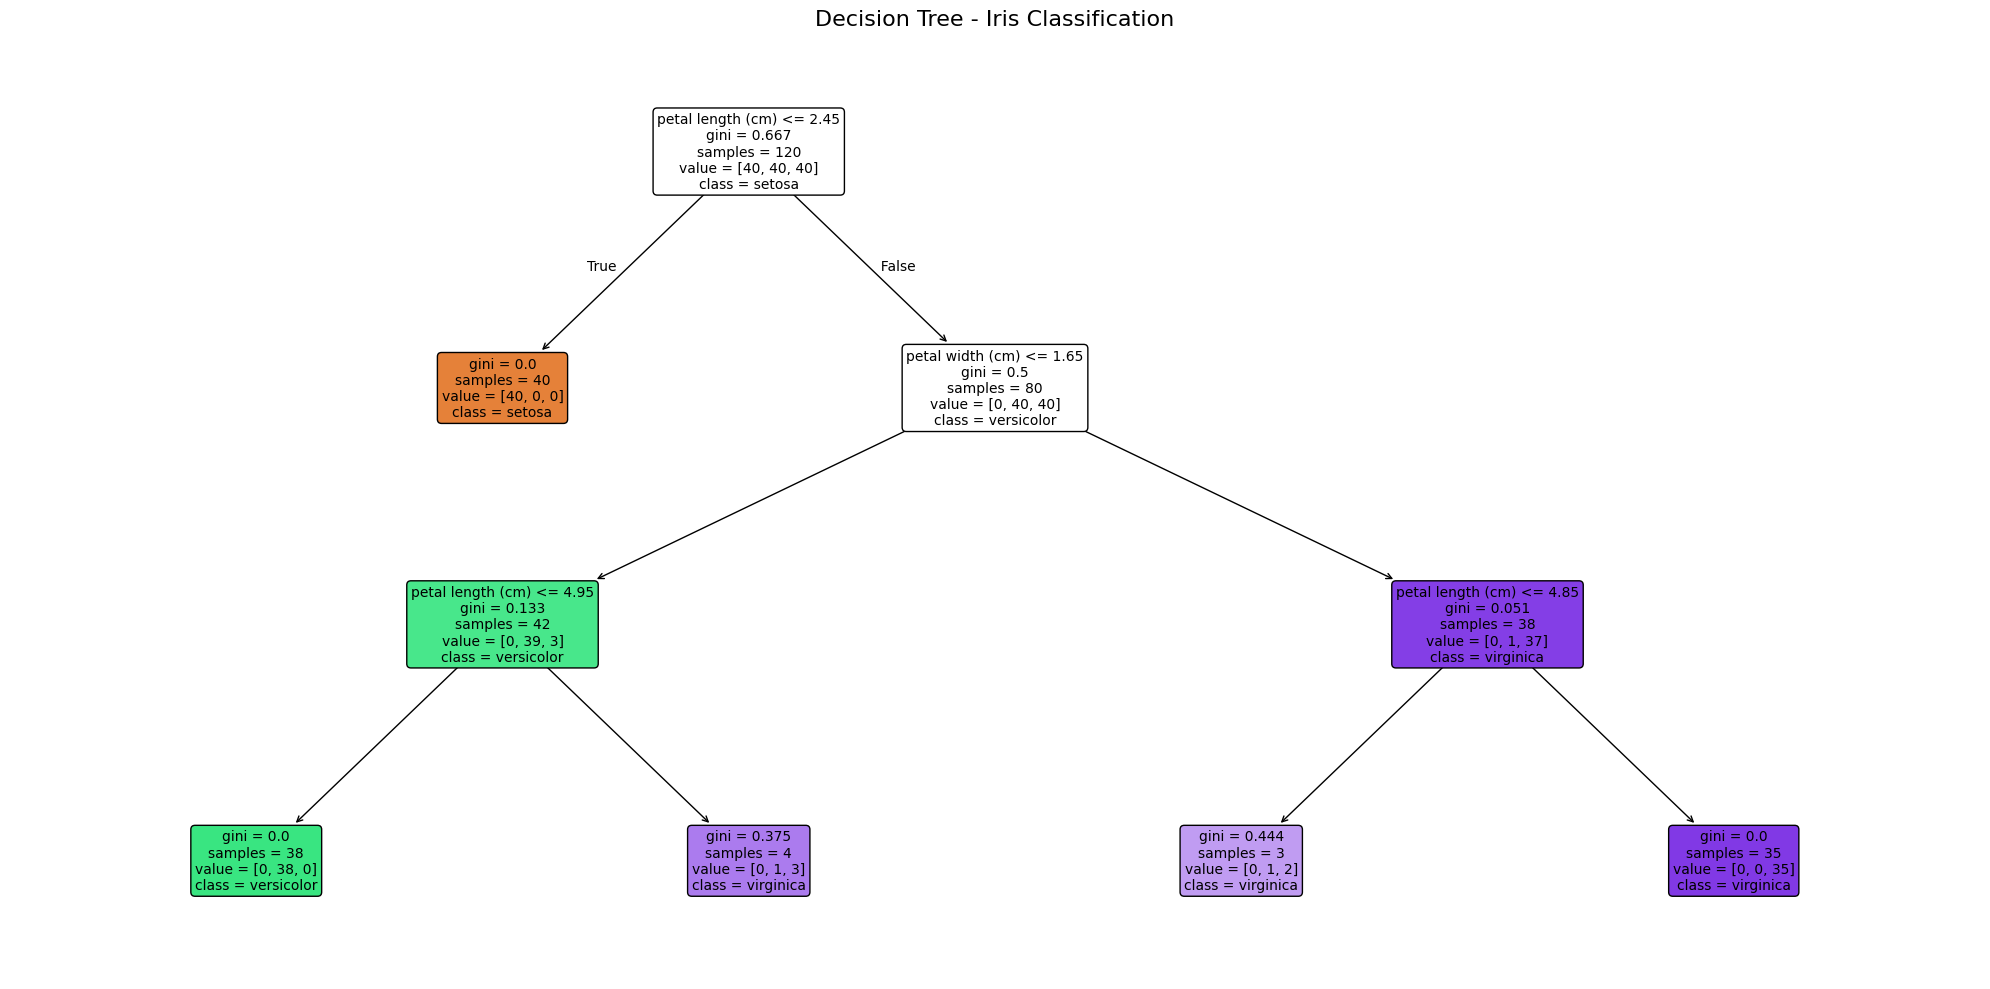


Decision Tree Rules:

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.65
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



In [13]:
# -------------------------------------------------------
# 10. DECISION TREE VISUALIZATION
# -------------------------------------------------------
plt.figure(figsize=(20,10))
plot_tree(model,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree - Iris Classification', fontsize=16)
plt.tight_layout()
plt.show()

# text version of tree rules
print("\nDecision Tree Rules:\n")
print(export_text(model, feature_names=list(iris.feature_names)))

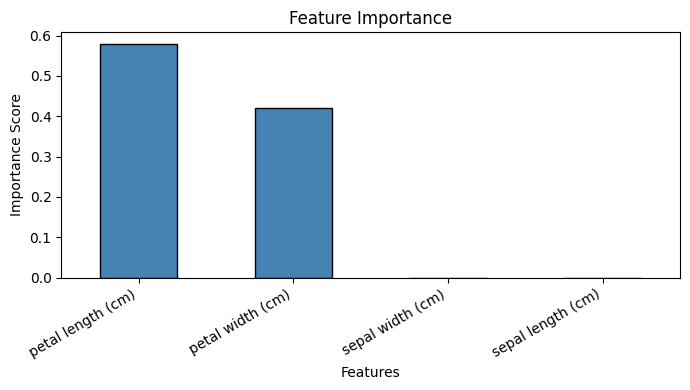


Feature Importances:
 petal length (cm)    0.579077
petal width (cm)     0.420923
sepal width (cm)     0.000000
sepal length (cm)    0.000000
dtype: float64


In [14]:
# -------------------------------------------------------
# 11. FEATURE IMPORTANCE
# -------------------------------------------------------
feat_imp = pd.Series(model.feature_importances_, index=iris.feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(7,4))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("\nFeature Importances:\n", feat_imp)

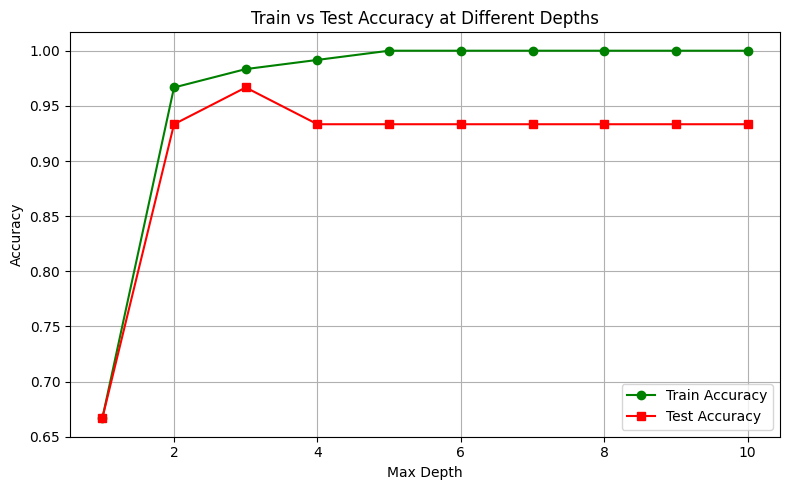


Best depth based on test accuracy: 3


In [15]:
# -------------------------------------------------------
# 12. OVERFITTING CHECK - Train vs Test Accuracy
# -------------------------------------------------------
train_acc, test_acc = [], []
depths = range(1, 11)

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    test_acc.append(accuracy_score(y_test,  m.predict(X_test)))

plt.figure(figsize=(8,5))
plt.plot(depths, train_acc, marker='o', label='Train Accuracy', color='green')
plt.plot(depths, test_acc,  marker='s', label='Test Accuracy',  color='red')
plt.title('Train vs Test Accuracy at Different Depths')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nBest depth based on test accuracy:", test_acc.index(max(test_acc)) + 1)
